In [ ]:
# Run only once 

!pip install pandas numpy matplotlib scikit-learn xgboost tensorflow ctgan shap scikeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 3.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 MB 3.4 MB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 3.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 1.4 MB/s eta 0:00:00a 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 1.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 1.1 MB/s eta 0:00:00a 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 1.0 MB/s eta 0:00:0000:0100:03m
  Attempting uninstall: protobuf━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/23 [libclang]
    Found existing installation: protobuf 5.29.3━━━━━━━━━━━━━━  1/23 [libclang]
    Uninstalling protobuf-5.29.3:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/23 [libclang]
      Successfully uninstalled protobuf-5.29.3━━━━━━━━━━━━━━━━

In [5]:
pip install scikeras shap

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 556 kB 415 kB/s eta 0:00:01
     |████████████████████████████████| 2.7 MB 3.8 MB/s eta 0:00:01
     |████████████████████████████████| 28.8 MB 1.1 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from math import pi

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import SpectralClustering
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from scikeras.wrappers import KerasRegressor

from ctgan import CTGAN

import shap

In [77]:
#load and clean dataset

def load_data(file_path):

    df = pd.read_csv(file_path)

    df.columns = (
        df.columns
        .str.strip()
        .str.replace('\ufeff', '')
    )

    df['name'] = df['name'].astype(str).str.strip()

    df['team_name'] = (
        df['team_name']
        .astype(str)
        .str.strip()
    )

    df['position_short'] = (
        df['position_short']
        .astype(str)
        .str.upper()
        .str.strip()
    )

    df['position_short'] = (
        df['position_short']
        .replace({
            'F':'FW',
            'FWD':'FW',
            'ST':'FW',

            'M':'MF',
            'MID':'MF',

            'D':'DF',
            'DEF':'DF',

            'GK':'GK',
            'G':'GK'
        })
    )

    for col in df.columns:

        if df[col].dtype == "object":

            df[col] = df[col].fillna("Unknown")

            df[col] = df[col].astype(str)

        else:

            df[col] = df[col].fillna(0)
    return df

In [3]:
for col in df.select_dtypes(include=['object']).columns:

    bad = df[col].apply(lambda x: isinstance(x, (int, float)))

    if bad.any():

        print(col)

NameError: name 'df' is not defined

In [78]:
#load dataset

file_path = "/Users/aranyabasu/Desktop/dataanalysislearning/project_final/source_code/final_year_project_dataset.csv"

df = load_data(file_path)

print(df.shape)

df.head()

(564, 92)


,tour_id,tour_name,id,jersey_no,name,short_name,position_id,position,position_short,team_id,...,goaltenders.catches,goaltenders.punches,goaltenders.penalty_kicks.shots_faced,goaltenders.penalty_kicks.goals_allowed,goaltenders.penalty_kicks.saves,country_id,country_name,dob,player_foot,height
0,148.0,ISL6,1514.0,3.0,Asamoah Gyan,Asamoah Gyan,2.0,Forward,FW,504.0,...,0.0,0.0,0.0,0.0,0.0,43.0,Ghana,Unknown,Unknown,0.0
1,148.0,ISL6,2475.0,26.0,Deshorn Dwayne Brown,Deshorn Brown,2.0,Forward,FW,656.0,...,0.0,0.0,0.0,0.0,0.0,56.0,Jamaica,12/22/1990,Right,187.0
2,148.0,ISL6,2900.0,9.0,Amine Chermiti,Amine Chermiti,2.0,Forward,FW,506.0,...,0.0,0.0,0.0,0.0,0.0,106.0,Tunisia,12/26/1987,left,177.0
3,148.0,ISL6,3753.0,7.0,Francisco Medina Luna,Piti,3.0,Midfielder,MF,1159.0,...,0.0,0.0,0.0,0.0,0.0,19.0,Spain,5/26/1981,left,179.0
4,148.0,ISL6,3809.0,4.0,Rafael Lopez Gomez,Rafael Lopez Gomez,1.0,Defender,DF,1536.0,...,0.0,0.0,0.0,0.0,0.0,19.0,Spain,04/09/1985,right,183.0


In [11]:

import ctgan
print(ctgan.__version__)


0.12.1


In [79]:
object_cols = df.select_dtypes(include=['object']).columns

for col in object_cols:

    df[col] = df[col].replace(0, np.nan)

    df[col] = df[col].fillna("Unknown")

    df[col] = df[col].astype(str)

print("Cleaning completed")

Cleaning completed


In [80]:
for col in object_cols:

    bad = df[col].apply(
        lambda x: not isinstance(x, str)
    )

    if bad.any():

        print(
            col,
            "still contains non-string values"
        )

In [81]:
#CTGAN Augmentation

categorical_columns = list(
    df.select_dtypes(include=['object']).columns
)

print(categorical_columns)

print("Training CTGAN...")

ctgan = CTGAN(
    epochs=500,
    verbose=True
)
  

ctgan.fit(
    df,
    categorical_columns
)

synthetic_df = ctgan.sample(2500)

df_augmented = pd.concat(
    [df, synthetic_df],
    ignore_index=True
)

print("Original Dataset:", len(df))
print("Synthetic Dataset:", len(synthetic_df))
print("Final Dataset:", len(df_augmented))



['tour_name', 'name', 'short_name', 'position', 'position_short', 'team_name', 'team_short_name', 'country_name', 'dob', 'player_foot']
Training CTGAN...


Gen. (-01.05) | Discrim. (-00.52): 100%|██████████| 500/500 [05:30<00:00,  1.51it/s]


Original Dataset: 564
Synthetic Dataset: 2500
Final Dataset: 3064


In [82]:
df_augmented.to_csv(
    r"/Users/aranyabasu/Desktop/dataanalysislearning/project_final/dataset/augmented_dataset.csv",
    index=False
)

In [ ]:
#print(df.dtypes)

tour_id         float64
tour_name        object
id              float64
jersey_no       float64
name             object
                 ...   
country_id      float64
country_name     object
dob              object
player_foot      object
height          float64
Length: 92, dtype: object


In [83]:
#Position Selection
position_input = "FW"

In [84]:
#Feature Selection
if position_input == 'FW':

    stats = [

        'events.goals',

        'events.assists',

        'events.shots_on_target',

        'events.key_passes',

        'events.penalties_earned',

        'touches.successful_passes',

        'touches.take_on_successful'
    ]

elif position_input == 'MF':

    stats = [

        'events.assists',

        'events.key_passes',

        'events.chances_created',

        'touches.successful_passes',

        'touches.interceptions',

        'events.goals'
    ]

elif position_input == 'DF':

    stats = [

        'touches.tackles',

        'touches.blocks',

        'touches.interceptions',

        'touches.clearance',

        'events.cleansheet',

        'touches.successful_passes'
    ]

elif position_input == 'GK':

    stats = [

        'goaltenders.saves',

        'goaltenders.shots_faced',

        'events.cleansheet',

        'goaltenders.penalty_kicks.saves',

        'goaltenders.goals_allowed'
    ]

In [85]:
#Create Position Dataset
position_df = (
    df_augmented[
        df_augmented['position_short']
        == position_input
    ]
    .copy()
)

X = position_df[
    stats
].astype(float)

if position_input == "GK":

    X['goaltenders.goals_allowed'] = (
        -X['goaltenders.goals_allowed']
    )

    X['goaltenders.shots_faced'] = (
        -X['goaltenders.shots_faced']
    )

print(X.shape)

X.head()

(719, 7)


,events.goals,events.assists,events.shots_on_target,events.key_passes,events.penalties_earned,touches.successful_passes,touches.take_on_successful
0,4.0,1.0,9.0,9.0,0.0,0.0,0.0
1,3.0,0.0,8.0,3.0,0.0,0.0,8.0
2,6.0,0.0,10.0,16.0,0.0,0.0,0.0
7,1.0,0.0,2.0,0.0,0.0,0.0,0.0
18,3.0,2.0,11.0,9.0,0.0,0.0,4.0


In [86]:
#XGB Feature Weights

def compute_xgb_weights(X):

    X_numeric = X.astype(float)

    # Proxy target
    y_proxy = X_numeric.sum(axis=1)

    xgb_model = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    )

    xgb_model.fit(
        X_numeric,
        y_proxy
    )

    weights = xgb_model.feature_importances_

    weights = weights / weights.sum()

    return weights, xgb_model

In [16]:
#ANN Feature Weights

def compute_ann_weights(X):

    X_numeric = X.astype(float)

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X_numeric)

    y_proxy = X_numeric.sum(axis=1)

    ann = Sequential([

        Dense(
            64,
            activation='relu',
            input_shape=(X_scaled.shape[1],)
        ),

        Dense(
            32,
            activation='relu'
        ),

        Dense(1)

    ])

    ann.compile(
        optimizer='adam',
        loss='mse'
    )

    ann.fit(
        X_scaled,
        y_proxy,
        epochs=100,
        batch_size=32,
        verbose=0
    )

    first_layer_weights = ann.layers[0].get_weights()[0]

    feature_importance = np.mean(
        np.abs(first_layer_weights),
        axis=1
    )

    feature_importance = (
        feature_importance /
        feature_importance.sum()
    )

    return feature_importance

In [87]:
#DNN Feature Weights

def compute_dnn_weights(X):

    X_numeric = X.astype(float)

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X_numeric)

    y_proxy = X_numeric.sum(axis=1)

    dnn = Sequential([

        Dense(
            256,
            activation='relu',
            input_shape=(X_scaled.shape[1],)
        ),

        Dropout(0.3),

        Dense(
            128,
            activation='relu'
        ),

        Dropout(0.3),

        Dense(
            64,
            activation='relu'
        ),

        Dense(
            32,
            activation='relu'
        ),

        Dense(1)

    ])

    dnn.compile(
        optimizer='adam',
        loss='mse'
    )

    dnn.fit(
        X_scaled,
        y_proxy,
        epochs=150,
        batch_size=32,
        verbose=0
    )

    first_layer_weights = dnn.layers[0].get_weights()[0]

    feature_importance = np.mean(
        np.abs(first_layer_weights),
        axis=1
    )

    feature_importance = (
        feature_importance /
        feature_importance.sum()
    )

    return feature_importance

In [88]:
#Compute All Weights

weights_xgb, xgb_model = compute_xgb_weights(X)

weights_ann = compute_ann_weights(X)

weights_dnn = compute_dnn_weights(X)

weight_table = pd.DataFrame({

    'Feature': stats,

    'XGB_Weight': weights_xgb,

    'ANN_Weight': weights_ann,

    'DNN_Weight': weights_dnn

})

weight_table

/Users/aranyabasu/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/aranyabasu/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


,Feature,XGB_Weight,ANN_Weight,DNN_Weight
0,events.goals,0.045731,0.146551,0.125626
1,events.assists,0.037577,0.131169,0.103342
2,events.shots_on_target,0.370731,0.176075,0.228570
3,events.key_passes,0.233026,0.162990,0.196547
4,events.penalties_earned,0.011514,0.095003,0.061233
5,touches.successful_passes,0.004450,0.110172,0.064053
6,touches.take_on_successful,0.296972,0.178041,0.220630


In [89]:
#Calculate Player Scores

position_df['Score_XGB'] = X.dot(
    weights_xgb
)

position_df['Score_ANN'] = X.dot(
    weights_ann
)

position_df['Score_DNN'] = X.dot(
    weights_dnn
)

position_df[
    [
        'name',
        'team_name',
        'Score_XGB',
        'Score_ANN',
        'Score_DNN'
    ]
].head()

,name,team_name,Score_XGB,Score_ANN,Score_DNN
0,Asamoah Gyan,NorthEast United FC,5.654316,3.768949,4.431902
1,Deshorn Dwayne Brown,Bengaluru FC,6.177892,3.761546,4.560118
2,Amine Chermiti,Mumbai City FC,7.710116,5.247883,6.184212
7,Thongkhosiem Haokip,Bengaluru FC,0.787193,0.498700,0.582767
18,Pape Amodou Sougou,Mumbai City FC,7.575511,4.817882,5.749277


In [90]:
#Top 10 Rankings

def get_top10(score_column):

    top_players = (

        position_df

        .sort_values(
            by=score_column,
            ascending=False
        )

        .drop_duplicates(
            subset='name',
            keep='first'
        )

    )

    return top_players[
        [
            'name',
            'team_name',
            score_column
        ]
    ].head(10)

In [55]:
#Display Rankings

print("\nTOP 10 PLAYERS - XGB\n")

display(
    get_top10(
        'Score_XGB'
    )
)

print("\nTOP 10 PLAYERS - ANN\n")

display(
    get_top10(
        'Score_ANN'
    )
)

print("\nTOP 10 PLAYERS - DNN\n")

display(
    get_top10(
        'Score_DNN'
    )
)


TOP 10 PLAYERS - XGB



,name,team_name,Score_XGB
313,Roy Krishna,ATK Mohun Bagan,22.580289
536,Luis Miguel Vieira Babo Machado,NorthEast United FC,19.117525
540,Jordan Murray,Kerala Blasters FC,17.362246
113,Marcelo Leite Pereira,Hyderabad FC,17.041451
126,Ferran Corominas Telechea,FC Goa,16.506482
544,Diego Mauricio Machado de Brito,Odisha FC,16.385126
20,Nerijus Valskis,Chennaiyin FC,15.811134
220,Bartholomew Ogbeche,Kerala Blasters FC,14.994962
334,Sunil Chhetri,Bengaluru FC,14.861326
490,Aridane Jesus Santana Cabrera,Hyderabad FC,14.782954



TOP 10 PLAYERS - ANN



,name,team_name,Score_ANN
313,Roy Krishna,ATK Mohun Bagan,15.375436
536,Luis Miguel Vieira Babo Machado,NorthEast United FC,12.835087
113,Marcelo Leite Pereira,Hyderabad FC,11.102935
126,Ferran Corominas Telechea,FC Goa,10.998045
540,Jordan Murray,Kerala Blasters FC,10.835006
348,Bright Enobakhare,SC East Bengal,10.819453
544,Diego Mauricio Machado de Brito,Odisha FC,10.742632
20,Nerijus Valskis,Chennaiyin FC,10.627506
242,Martin Nicolas Chaves Garcia,NorthEast United FC,9.792484
220,Bartholomew Ogbeche,Kerala Blasters FC,9.776975



TOP 10 PLAYERS - DNN



,name,team_name,Score_DNN
313,Roy Krishna,ATK Mohun Bagan,18.296400
536,Luis Miguel Vieira Babo Machado,NorthEast United FC,15.772495
348,Bright Enobakhare,SC East Bengal,13.691625
113,Marcelo Leite Pereira,Hyderabad FC,13.521507
540,Jordan Murray,Kerala Blasters FC,13.212627
126,Ferran Corominas Telechea,FC Goa,12.977043
544,Diego Mauricio Machado de Brito,Odisha FC,12.933783
20,Nerijus Valskis,Chennaiyin FC,12.236677
242,Martin Nicolas Chaves Garcia,NorthEast United FC,12.089410
400,Manvir Singh,ATK Mohun Bagan,11.477110


In [91]:
#Spectral Clustering

scaler = StandardScaler()

scaled_features = scaler.fit_transform(X)

spectral = SpectralClustering(
    n_clusters=3,
    affinity='nearest_neighbors',
    random_state=42
)

position_df['Cluster'] = spectral.fit_predict(
    scaled_features
)

print(
    position_df[
        ['name', 'team_name', 'Cluster']
    ].head(10)
)

                      name            team_name  Cluster
0             Asamoah Gyan  NorthEast United FC        1
1     Deshorn Dwayne Brown         Bengaluru FC        0
2           Amine Chermiti       Mumbai City FC        1
7      Thongkhosiem Haokip         Bengaluru FC        0
18      Pape Amodou Sougou       Mumbai City FC        1
19          Andre Schembri        Chennaiyin FC        1
20         Nerijus Valskis        Chennaiyin FC        1
45       Jayesh Dilip Rane               ATK FC        0
54             Roy Krishna               ATK FC        1
55  Sergio Castel Martínez        Jamshedpur FC        1


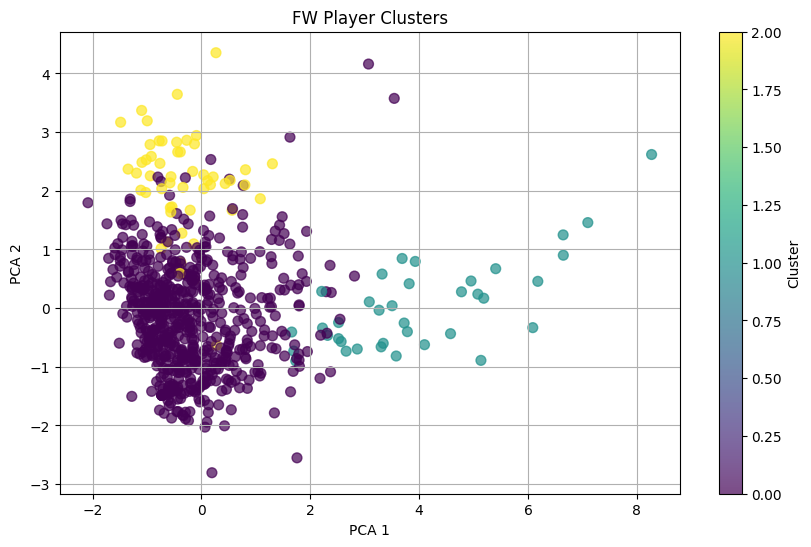

In [92]:
#PCA Visualuzation

pca = PCA(
    n_components=2
)

pca_result = pca.fit_transform(
    scaled_features
)

plt.figure(
    figsize=(10,6)
)

scatter = plt.scatter(
    pca_result[:,0],
    pca_result[:,1],
    c=position_df['Cluster'],
    cmap='viridis',
    s=50,
    alpha=0.7
)

plt.title(
    f'{position_input} Player Clusters'
)

plt.xlabel('PCA 1')

plt.ylabel('PCA 2')

plt.colorbar(
    scatter,
    label='Cluster'
)

plt.grid(True)

plt.show()

In [93]:
#Combined Ranking Table

agg_df = position_df.groupby(
    ['name','team_name'],
    as_index=False
).agg({

    'Score_XGB':'max',

    'Score_ANN':'max',

    'Score_DNN':'max'

})

In [94]:
#Generate Ranks

agg_df['Rank_XGB'] = (
    agg_df['Score_XGB']
    .rank(
        ascending=False,
        method='min'
    )
    .astype(int)
)

agg_df['Rank_ANN'] = (
    agg_df['Score_ANN']
    .rank(
        ascending=False,
        method='min'
    )
    .astype(int)
)

agg_df['Rank_DNN'] = (
    agg_df['Score_DNN']
    .rank(
        ascending=False,
        method='min'
    )
    .astype(int)
)

agg_df['Average_Rank'] = (

    agg_df[
        [
            'Rank_XGB',
            'Rank_ANN',
            'Rank_DNN'
        ]
    ]

    .mean(axis=1)

)

combined_rank_table = (

    agg_df

    .sort_values(
        by='Average_Rank'
    )

)

combined_rank_table.head(20)

,name,team_name,Score_XGB,Score_ANN,Score_DNN,Rank_XGB,Rank_ANN,Rank_DNN,Average_Rank
525,Roy Krishna,ATK Mohun Bagan,23.200164,16.037235,18.700775,2,1,1,1.333333
492,Rahul Shankar Bheke,Hyderabad FC,25.327656,14.776274,18.334523,1,2,2,1.666667
353,Luis Miguel Vieira Babo Machado,NorthEast United FC,21.673412,13.657496,16.495863,4,3,3,3.333333
329,Lalhrezuala Sailung,Mumbai City FC,21.195075,13.178530,16.117354,5,4,4,4.333333
568,Soram Poireiangaba Meitei,Jamshedpur FC,21.696878,12.974144,15.860278,3,5,5,4.333333
86,Bright Enobakhare,SC East Bengal,19.271217,11.998191,14.644104,9,7,7,7.666667
463,Prabir Das,Mumbai City FC,19.314141,11.885793,14.625410,8,8,8,8.000000
524,Roy Krishna,ATK FC,18.627097,12.963431,15.009883,12,6,6,8.000000
127,Dimas Delgado Morgado,Bengaluru FC,20.028984,11.600872,14.430219,6,11,9,8.666667
197,Francisco Perdomo Borges,SC East Bengal,19.620087,11.445213,14.248379,7,13,10,10.000000


In [95]:
#Select Ranking Method

method_input = "ANN"

In [96]:
#Choose Ranking Table

if method_input == "XGB":

    chosen_score_col = "Score_XGB"

elif method_input == "ANN":

    chosen_score_col = "Score_ANN"

else:

    chosen_score_col = "Score_DNN"

In [97]:
#Top Players Based On Selected Method

chosen_top_players = (

    position_df

    .sort_values(
        by=chosen_score_col,
        ascending=False
    )

    .drop_duplicates(
        subset='name',
        keep='first'
    )

)

chosen_top_players[
    [
        'name',
        'team_name',
        chosen_score_col
    ]
].head(10)

,name,team_name,Score_ANN
313,Roy Krishna,ATK Mohun Bagan,16.037235
2780,Rahul Shankar Bheke,Hyderabad FC,14.776274
536,Luis Miguel Vieira Babo Machado,NorthEast United FC,13.657496
2828,Lalhrezuala Sailung,Mumbai City FC,13.178530
1562,Soram Poireiangaba Meitei,Jamshedpur FC,12.974144
348,Bright Enobakhare,SC East Bengal,11.998191
2162,Prabir Das,Mumbai City FC,11.885793
1878,Laldinliana Renthlei,NorthEast United FC,11.792153
113,Marcelo Leite Pereira,Hyderabad FC,11.744199
3009,Dimas Delgado Morgado,Bengaluru FC,11.600872


In [98]:
#Radar Chart Function

from math import pi

def plot_radar(
    player1_stats,
    player2_stats,
    stats_labels,
    player1,
    player2
):

    angles = [

        n / float(len(stats_labels))

        * 2 * pi

        for n in range(
            len(stats_labels)
        )

    ]

    angles += angles[:1]

    player1_stats = np.append(
        player1_stats,
        player1_stats[0]
    )

    player2_stats = np.append(
        player2_stats,
        player2_stats[0]
    )

    fig, ax = plt.subplots(
        figsize=(10,8),
        subplot_kw=dict(
            polar=True
        )
    )

    ax.plot(
        angles,
        player1_stats,
        linewidth=2,
        label=player1
    )

    ax.fill(
        angles,
        player1_stats,
        alpha=0.25
    )

    ax.plot(
        angles,
        player2_stats,
        linewidth=2,
        label=player2,
        color='orange'
    )

    ax.fill(
        angles,
        player2_stats,
        alpha=0.25,
        color='orange'
    )

    ax.set_xticks(
        angles[:-1]
    )

    ax.set_xticklabels(
        stats_labels
    )

    ax.set_yticklabels([])

    ax.legend()

    plt.show()

In [99]:
#Select 2 Players

player1 = "Roy Krishna"

player2 = "Luis Miguel Vieira Babo Machado"

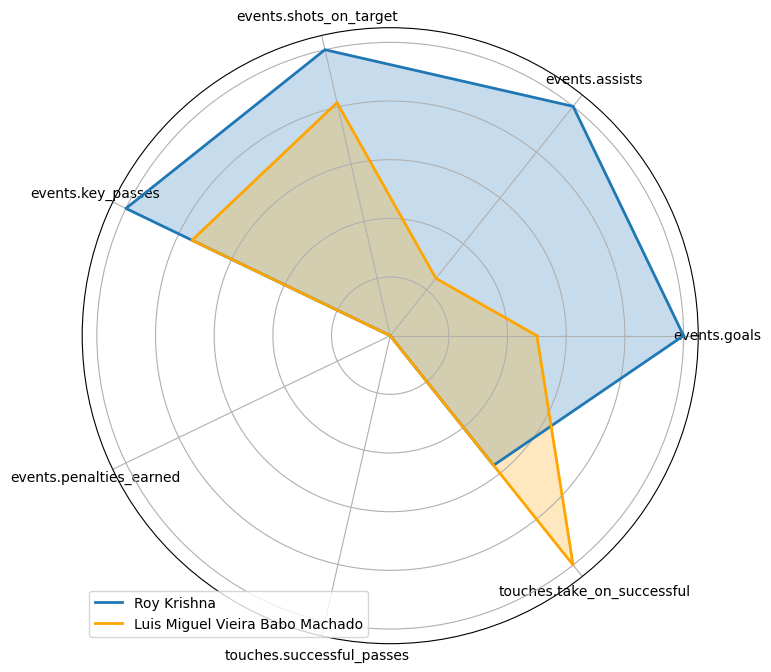

In [100]:
#Compare Players

row1 = chosen_top_players[
    chosen_top_players['name']
    == player1
]

row2 = chosen_top_players[
    chosen_top_players['name']
    == player2
]

values1 = (
    row1.iloc[0][stats]
    .values
    .astype(float)
)

values2 = (
    row2.iloc[0][stats]
    .values
    .astype(float)
)

max_vals = np.maximum(
    values1,
    values2
)

values1_norm = np.divide(
    values1,
    max_vals,
    out=np.zeros_like(values1),
    where=max_vals!=0
)

values2_norm = np.divide(
    values2,
    max_vals,
    out=np.zeros_like(values2),
    where=max_vals!=0
)

plot_radar(
    values1_norm,
    values2_norm,
    stats,
    player1,
    player2
)

In [101]:
#Playing Style Similarity

cluster1 = int(
    row1['Cluster'].values[0]
)

cluster2 = int(
    row2['Cluster'].values[0]
)

print(
    f"{player1} Cluster:",
    cluster1
)

print(
    f"{player2} Cluster:",
    cluster2
)

if cluster1 == cluster2:

    print(
        "Players have similar playing styles."
    )

else:

    print(
        "Players have different playing styles."
    )

Roy Krishna Cluster: 1
Luis Miguel Vieira Babo Machado Cluster: 1
Players have similar playing styles.


In [102]:
#Feature Weight Comparison Table

comparison_weights = pd.DataFrame({

    'Feature': stats,

    'XGB': weights_xgb,

    'ANN': weights_ann,

    'DNN': weights_dnn

})

comparison_weights

,Feature,XGB,ANN,DNN
0,events.goals,0.045731,0.146551,0.125626
1,events.assists,0.037577,0.131169,0.103342
2,events.shots_on_target,0.370731,0.176075,0.228570
3,events.key_passes,0.233026,0.162990,0.196547
4,events.penalties_earned,0.011514,0.095003,0.061233
5,touches.successful_passes,0.004450,0.110172,0.064053
6,touches.take_on_successful,0.296972,0.178041,0.220630


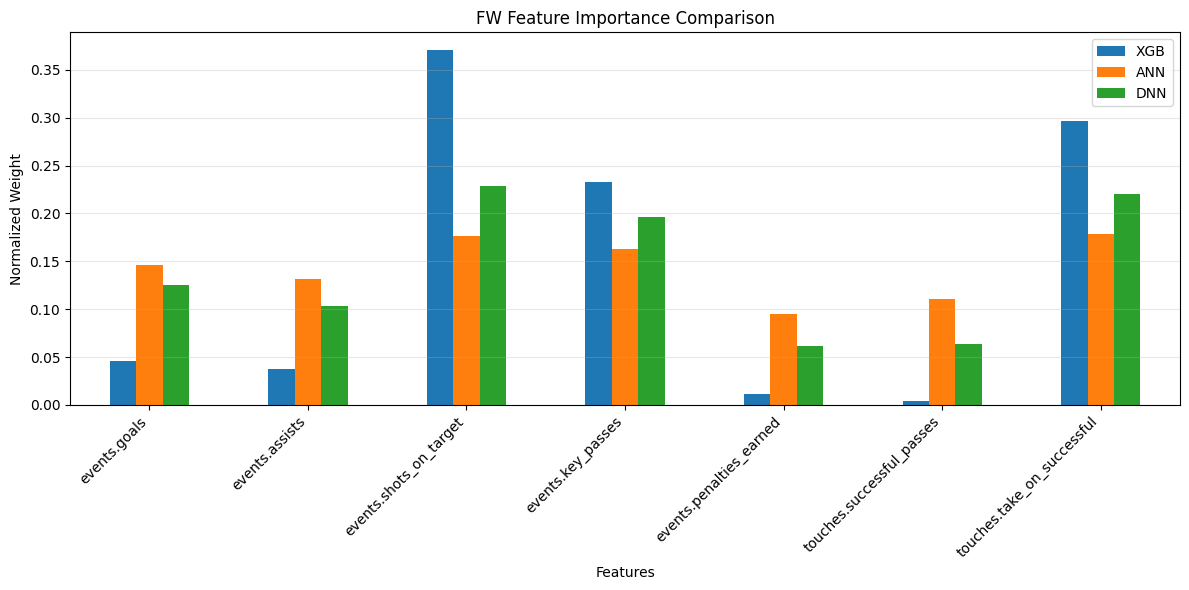

In [103]:
#Bar Chart Comparison

comparison_weights.set_index(
    'Feature'
).plot(

    kind='bar',

    figsize=(12,6)

)

plt.title(
    f'{position_input} Feature Importance Comparison'
)

plt.ylabel(
    'Normalized Weight'
)

plt.xlabel(
    'Features'
)

plt.xticks(
    rotation=45,
    ha='right'
)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()

In [70]:
#Top Features By Model

print("\nTop Features According to XGB")

display(

    comparison_weights

    .sort_values(
        by='XGB',
        ascending=False
    )

)

print("\nTop Features According to ANN")

display(

    comparison_weights

    .sort_values(
        by='ANN',
        ascending=False
    )

)

print("\nTop Features According to DNN")

display(

    comparison_weights

    .sort_values(
        by='DNN',
        ascending=False
    )

)



Top Features According to XGB


,Feature,XGB,ANN,DNN
2,events.shots_on_target,0.339923,0.163668,0.186111
3,events.key_passes,0.247262,0.160209,0.213031
6,touches.take_on_successful,0.166786,0.156441,0.201487
0,events.goals,0.155395,0.149093,0.156077
4,events.penalties_earned,0.045157,0.124650,0.073668
5,touches.successful_passes,0.025830,0.112459,0.069894
1,events.assists,0.019647,0.133480,0.099732



Top Features According to ANN


,Feature,XGB,ANN,DNN
2,events.shots_on_target,0.339923,0.163668,0.186111
3,events.key_passes,0.247262,0.160209,0.213031
6,touches.take_on_successful,0.166786,0.156441,0.201487
0,events.goals,0.155395,0.149093,0.156077
1,events.assists,0.019647,0.133480,0.099732
4,events.penalties_earned,0.045157,0.124650,0.073668
5,touches.successful_passes,0.025830,0.112459,0.069894



Top Features According to DNN


,Feature,XGB,ANN,DNN
3,events.key_passes,0.247262,0.160209,0.213031
6,touches.take_on_successful,0.166786,0.156441,0.201487
2,events.shots_on_target,0.339923,0.163668,0.186111
0,events.goals,0.155395,0.149093,0.156077
1,events.assists,0.019647,0.133480,0.099732
4,events.penalties_earned,0.045157,0.124650,0.073668
5,touches.successful_passes,0.025830,0.112459,0.069894


In [104]:
#Correlation Between Weighting Models

weight_corr = comparison_weights[
    ['XGB','ANN','DNN']
].corr()

weight_corr

,XGB,ANN,DNN
XGB,1.000000,0.892750,0.966092
ANN,0.892750,1.000000,0.972514
DNN,0.966092,0.972514,1.000000


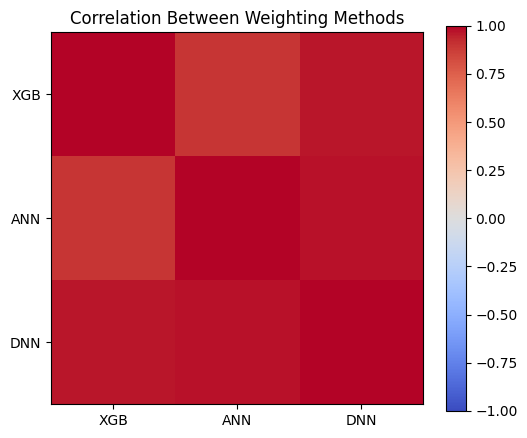

In [105]:
#Heatmap

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(
    weight_corr,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.colorbar()

plt.xticks(
    range(len(weight_corr.columns)),
    weight_corr.columns
)

plt.yticks(
    range(len(weight_corr.columns)),
    weight_corr.columns
)

plt.title(
    'Correlation Between Weighting Methods'
)

plt.show()

In [106]:
#K-Fold Comparison on Augmented Dataset

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

def evaluate_augmented_models(X):

    y = X.sum(axis=1)

    kf = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    rmse_xgb = []
    rmse_ann = []
    rmse_dnn = []

    for train_idx, test_idx in kf.split(X):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # =====================
        # Scaling
        # =====================

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # =====================
        # XGB
        # =====================

        xgb = XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            objective='reg:squarederror'
        )

        xgb.fit(
            X_train_scaled,
            y_train
        )

        pred_xgb = xgb.predict(
            X_test_scaled
        )

        rmse_xgb.append(
            np.sqrt(
                mean_squared_error(
                    y_test,
                    pred_xgb
                )
            )
        )

        # =====================
        # ANN
        # =====================

        ann = Sequential([

            Dense(
                64,
                activation='relu',
                input_shape=(
                    X_train_scaled.shape[1],
                )
            ),

            Dense(
                32,
                activation='relu'
            ),

            Dense(1)

        ])

        ann.compile(
            optimizer='adam',
            loss='mse'
        )

        ann.fit(
            X_train_scaled,
            y_train,
            epochs=100,
            batch_size=32,
            verbose=0
        )

        pred_ann = ann.predict(
            X_test_scaled,
            verbose=0
        ).flatten()

        rmse_ann.append(
            np.sqrt(
                mean_squared_error(
                    y_test,
                    pred_ann
                )
            )
        )

        # =====================
        # DNN
        # =====================

        dnn = Sequential([

            Dense(
                256,
                activation='relu',
                input_shape=(
                    X_train_scaled.shape[1],
                )
            ),

            Dropout(0.3),

            Dense(
                128,
                activation='relu'
            ),

            Dropout(0.3),

            Dense(
                64,
                activation='relu'
            ),

            Dense(
                32,
                activation='relu'
            ),

            Dense(1)

        ])

        dnn.compile(
            optimizer='adam',
            loss='mse'
        )

        dnn.fit(
            X_train_scaled,
            y_train,
            epochs=150,
            batch_size=32,
            verbose=0
        )

        pred_dnn = dnn.predict(
            X_test_scaled,
            verbose=0
        ).flatten()

        rmse_dnn.append(
            np.sqrt(
                mean_squared_error(
                    y_test,
                    pred_dnn
                )
            )
        )

    results = {

        'XGB': np.mean(rmse_xgb),

        'ANN': np.mean(rmse_ann),

        'DNN': np.mean(rmse_dnn)

    }

    return results

In [74]:
#Run Evaluation

results_augmented = evaluate_augmented_models(X)

print("\n===== AUGMENTED DATASET RESULTS =====\n")

for model, score in results_augmented.items():

    print(
        f"{model} RMSE : {score:.4f}"
    )

best_model = min(
    results_augmented,
    key=results_augmented.get
)

print(
    f"\nBest Model : {best_model}"
)

/Users/aranyabasu/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/aranyabasu/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/aranyabasu/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__i


===== AUGMENTED DATASET RESULTS =====

XGB RMSE : 2.4340
ANN RMSE : 0.3197
DNN RMSE : 0.8274

Best Model : ANN


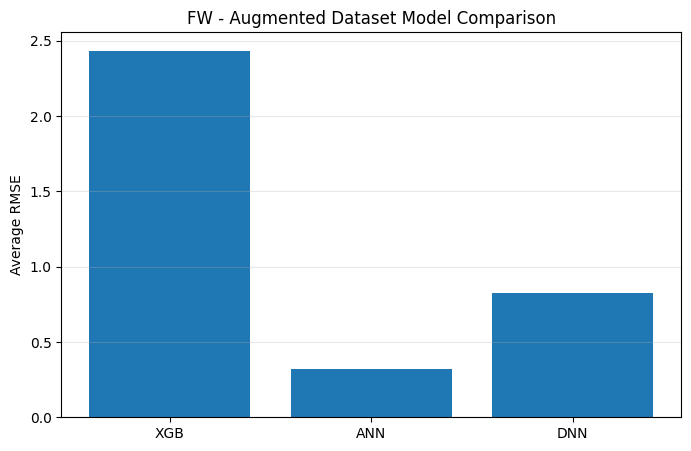

In [107]:
#Plot Comparison

plt.figure(
    figsize=(8,5)
)

plt.bar(
    results_augmented.keys(),
    results_augmented.values()
)

plt.ylabel(
    "Average RMSE"
)

plt.title(
    f"{position_input} - Augmented Dataset Model Comparison"
)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.show()

look at MCDM

 Objective of the Project

The objective of the project is to develop a football player evaluation and ranking system using machine learning and deep learning techniques.

The system:

Evaluates players separately by position
Forward (FW)
Midfielder (MF)
Defender (DF)
Goalkeeper (GK)
Generates feature importance weights using:
XGBoost (XGB)
Artificial Neural Network (ANN)
Deep Neural Network (DNN)
Calculates player scores using a weighted-sum approach
Groups players into playing-style clusters using Spectral Clustering
Visualizes clusters using PCA
Compares players using Radar Charts

CTGAN Data Augmentation
Why CTGAN?

The original dataset contains approximately: 563 players

This is relatively small for deep learning.
To increase the dataset size, CTGAN (Conditional Tabular GAN) is used.

How CTGAN Works:

CTGAN learns the statistical distribution of the original dataset.
It then generates realistic synthetic players having similar characteristics.

Example:

Original player:
Goals = 10
Assists = 5
Shots = 18

Synthetic player:
Goals = 9
Assists = 6
Shots = 20

Original Dataset
563 rows

Synthetic Players
2500 rows

Final Dataset
3063 rows
This provides more training samples for ANN and DNN.

Feature Weight Generation

The core idea of the project is:
Player Statistics
       ↓
Feature Weight Calculation
       ↓
Player Score Calculation
       ↓
Ranking

XGBoost Weight Generation:

A proxy target is created: y_proxy = X.sum(axis=1)

This represents overall contribution.

XGBoost is trained on: Features → Proxy Target

Feature importance values are extracted: xgb.feature_importances_

Then normalized: weight = importance / importance.sum()

These become XGB feature weights.

ANN Weight Generation:

An Artificial Neural Network is trained.

Architecture:

Input Layer
      ↓
64 Neurons
      ↓
32 Neurons
      ↓
Output Layer

After training: ann.layers[0].get_weights() is used.

The average absolute weight of each input feature is computed.
These values are normalized to obtain ANN feature weights.

DNN Weight Generation:

A deeper network is used.

Architecture:

Input
 ↓
256
 ↓
128
 ↓
64
 ↓
32
 ↓
Output

Dropout layers reduce overfitting.Again, first-layer weights are extracted and normalized.These become DNN feature weights.

Why K-Fold Cross Validation Was Used

If you simply split the dataset once:
    Training Data = 80%
    Testing Data = 20%

the result depends heavily on which players happen to fall into the training and testing sets.

For example:

Split 1:
Training → Messi, Ronaldo, Neymar
Testing  → Haaland

Split 2:
Training → Haaland, Neymar
Testing  → Messi

The accuracy can change significantly.

To avoid this problem, K-Fold Cross Validation evaluates the model multiple times on different splits.


How 5-Fold Cross Validation Works:

In my code:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

The dataset is divided into 5 equal parts.

Example:

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


Iteration 1
Train → Fold 2 + Fold 3 + Fold 4 + Fold 5
Test  → Fold 1

Iteration 2
Train → Fold 1 + Fold 3 + Fold 4 + Fold 5
Test  → Fold 2

Iteration 3
Train → Fold 1 + Fold 2 + Fold 4 + Fold 5
Test  → Fold 3

Iteration 4
Train → Fold 1 + Fold 2 + Fold 3 + Fold 5
Test  → Fold 4

Iteration 5
Train → Fold 1 + Fold 2 + Fold 3 + Fold 4
Test  → Fold 5

Every sample is used:

4 times for training
1 time for testing

What Happened in Your Code

Inside each fold: rf.fit(X_train, y_train)

Random Forest is trained.

Then: pred_rf = rf.predict(X_test)

Predictions are generated.

Then RMSE is calculated:

rmse_rf.append(
    np.sqrt(
        mean_squared_error(
            y_test,
            pred_rf
        )
    )
)

The same process is repeated for:

Random Forest
XGBoost
Deep Learning


3way-split(train-test-validation),
statification,
content dependent metric selection,
check for underfitting and overfitting separately